## 1. Setup: librerías

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 2. Carga de Datos

In [42]:
df = pd.read_csv('insurance_cross_sell.csv')
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 3. Análisis Exploratorio (EDA)

Se revisa la calidad de los datos (nulos) y se confirma el desbalance de clases: 87.7% no interesados vs. 12.3% interesados. Este desbalance determina las decisiones de modelado más adelante.

In [43]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [44]:
df['Response'].value_counts(normalize=True)

,proportion
Response,
0,0.877437
1,0.122563


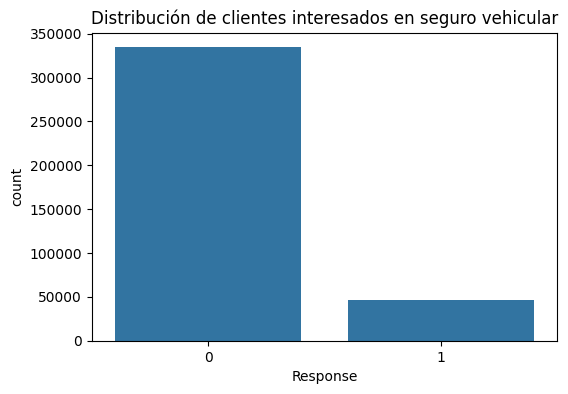

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)
plt.title('Distribución de clientes interesados en seguro vehicular')
plt.show()

## 4. Limpieza y codificación de variables categóricas

Se eliminan variables categóricas de texto convirtiéndolas a formato numérico (one-hot encoding) y se descarta `id` por no aportar valor predictivo.

In [46]:
df_clean = df.drop('id', axis=1)
df_clean = pd.get_dummies(df_clean, columns=['Gender', 'Vehicle_Age', 'Vehicle_Damage'], drop_first=True)
df_clean.head()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,44,1,28.0,0,40454.0,26.0,217,1,True,False,True,True
1,76,1,3.0,0,33536.0,26.0,183,0,True,False,False,False
2,47,1,28.0,0,38294.0,26.0,27,1,True,False,True,True
3,21,1,11.0,1,28619.0,152.0,203,0,True,True,False,False
4,29,1,41.0,1,27496.0,152.0,39,0,False,True,False,False


## 5. División train/test

Se usa `stratify=y` para que ambos conjuntos (train y test) mantengan la misma proporción de clases, dado el desbalance detectado.




In [47]:
X = df_clean.drop('Response', axis=1)
y = df_clean['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 6. Escalado y entrenamiento

Se escalan las variables numéricas porque están en escalas muy distintas (Annual_Premium en miles vs. variables binarias), lo cual afecta la convergencia del modelo. Se usa `class_weight='balanced'` porque, sin este ajuste, el modelo predecía siempre "no interesado" y no detectaba ningún cliente de la clase minoritaria (recall de 0.00).

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## 7. Evaluación

Se prioriza AUC y recall sobre accuracy, ya que con un dataset desbalanceado el accuracy es engañoso (predecir siempre "0" ya da 88% de accuracy sin aportar valor real al negocio).

In [49]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.97      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222

AUC: 0.8385162934614371


## 8. Matriz de confusión

Visualización de aciertos y errores por clase: permite ver directamente cuántos clientes interesados se identificaron correctamente (9,100) frente a los que se pasaron por alto (242).

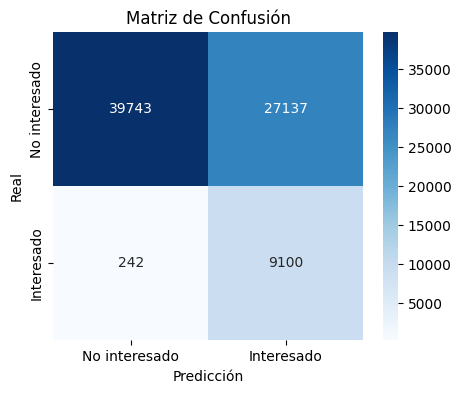

In [50]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No interesado','Interesado'], yticklabels=['No interesado','Interesado'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()